In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
simuls = pd.read_csv("simul.csv")
data_long = simuls.melt(
    id_vars=[c for c in simuls.columns if not c.startswith("Precision_quantile_")],
    value_vars=[c for c in simuls.columns if c.startswith("Precision_quantile_")],
    var_name="combined",
    value_name="Precision"
)

data_long[["Metric", "Quantile"]] = data_long["combined"].str.extract(r"(.*)_quantile_(.*)")
data_long["Quantile"] = data_long["Quantile"].astype(float).round(4)
data_long = data_long.drop(columns="combined")

Axes(0.125,0.11;0.775x0.77)
['OT', 'OT regularized, similarity']
[np.float64(0.0), np.float64(0.1), np.float64(1.0), np.float64(10.0), np.float64(100.0), np.float64(1000.0)]
0      0.169957
22     0.178406
44     0.184130
66     0.195907
88     0.209211
110    0.223334
132    0.237061
154    0.248675
176    0.253376
198    0.286930
220    0.317467
242    0.359440
264    0.388717
286    0.425550
308    0.516560
330    0.515948
352    0.567257
Name: Precision, dtype: float64
0      0.950
22     0.953
44     0.956
66     0.959
88     0.962
110    0.965
132    0.968
154    0.971
176    0.974
198    0.977
220    0.980
242    0.983
264    0.986
286    0.989
308    0.992
330    0.995
352    0.998
Name: Quantile, dtype: float64
1      0.233226
23     0.249860
45     0.258233
67     0.271851
89     0.284428
111    0.308381
133    0.340425
155    0.361461
177    0.393495
199    0.427524
221    0.449277
243    0.476220
265    0.523420
287    0.582631
309    0.594539
331    0.500661
353    0.32157

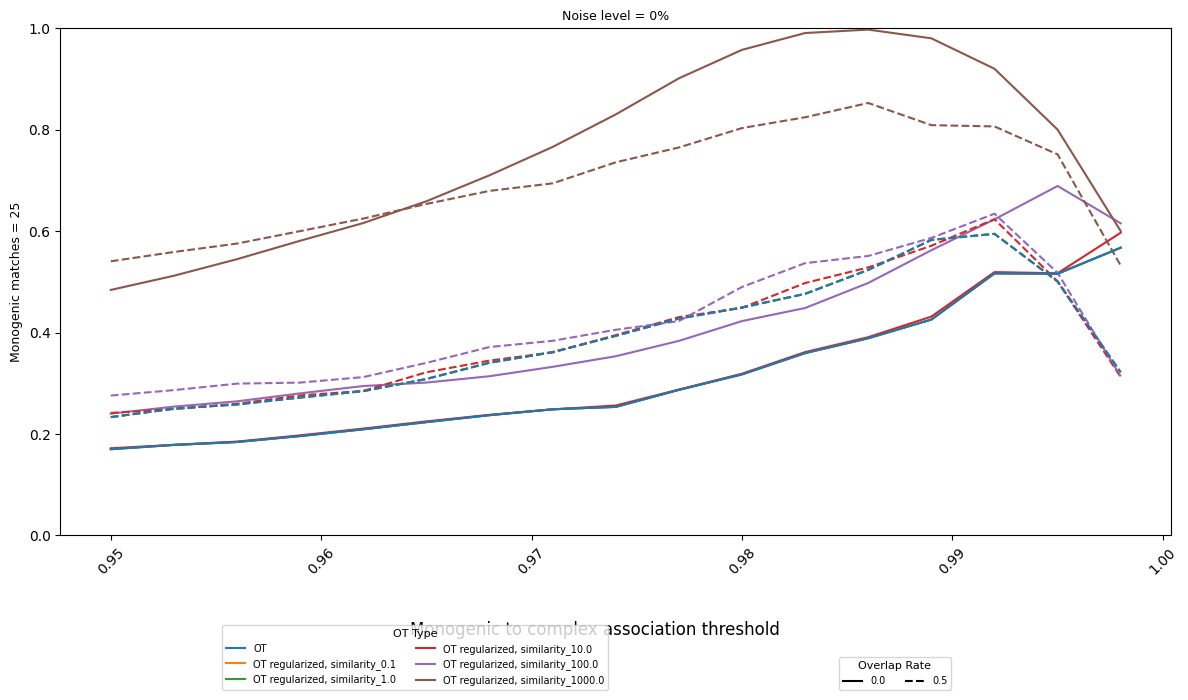

In [ ]:
# Valeurs uniques pour la grille
n_matches = sorted(data_long["n_match"].unique())
noise_levels = sorted(data_long["noise_level"].unique())

# Plot
fig, axes = plt.subplots(
    len(n_matches), len(noise_levels),
    figsize=(12, 7),
    sharex=True, sharey=True
)
print(axes)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
#ot_types = sorted(data_long["OT_type"].unique())
ot_types = ['OT', 'OT regularized, similarity']
overlap_rates = sorted(data_long["overlap_rate"].unique())
etas = sorted(data_long["eta"].unique())
linestyles = ["-", "--", "-.", ":"]

color_map = {}
idx = 0
for ot in ot_types:
    if ot == 'OT':
        color_map[(ot, None)] = colors[idx % len(colors)]
        idx += 1
    else:
        for eta in etas:
            if eta != 0.0:
                color_map[(ot, eta)] = colors[idx % len(colors)]
                idx += 1

for i, n_match in enumerate(n_matches):
    for j, noise in enumerate(noise_levels):
        if len(n_matches)==1 and len(noise_levels)==1:
            ax = axes
        elif len(n_matches) == 1:
            ax = axes[j]
        elif len(noise_levels) == 1:
            ax = axes[i]
        else:
            ax = axes[i, j]
        subset = data_long[(data_long["n_match"] == n_match) & (data_long["noise_level"] == noise)]

        for k, ot in enumerate(ot_types):
            for l, rate in enumerate(overlap_rates):
                if ot == 'OT':
                    sub = subset[(subset["OT_type"] == ot) & (subset["overlap_rate"] == rate) & (subset["eta"] == 0.0)]
                    print(sub["Precision"])
                    print(sub["Quantile"])
                    ax.plot(
                        sub["Quantile"], sub["Precision"],
                        color=color_map[(ot, None)],
                        linestyle=linestyles[l % len(linestyles)],
                        zorder=10,
                        label=f"{ot} / {rate}"
                    )
                else : 
                    for e, eta in enumerate(etas):
                        if eta != 0.0 :
                            sub = subset[(subset["OT_type"] == ot) & (subset["overlap_rate"] == rate) & (subset["eta"] == eta)]
                            ax.plot(
                                sub["Quantile"], sub["Precision"],
                                color=color_map[(ot, eta)],
                                linestyle=linestyles[l % len(linestyles)],
                                label=f"{ot} / {rate}/ {eta}" if i == 0 and j == 0 else ""
                            )

        ax.set_ylim(0, 1)
        ax.tick_params(axis="x", rotation=45)

        if i == 0:
            ax.set_title(f"Noise level = {noise * 100:.0f}%", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"Monogenic matches = {n_match}", fontsize=9)

# Légendes séparées pour OT_type et overlap_rate
ot_handles = []
for k, ot in enumerate(ot_types):
    if ot == 'OT':
        ot_handles.append(plt.Line2D([0], [0], color=color_map[(ot, None)], label=f"{str(ot)}"))
    else :
        for e, eta in enumerate(etas):
            if eta != 0.0:
                ot_handles.append(plt.Line2D([0], [0], color=color_map[(ot, eta)], label=f"{str(ot)}_{eta}"))
rate_handles = [plt.Line2D([0], [0], color="black", linestyle=linestyles[l % len(linestyles)], label=str(r)) for l, r in enumerate(overlap_rates)]

fig.legend(handles=ot_handles, loc="lower center", ncol=len(ot_types), bbox_to_anchor=(0.35, 0), fontsize=7, title="OT Type", title_fontsize=8)
fig.legend(handles=rate_handles, loc="lower center", ncol=len(overlap_rates), bbox_to_anchor=(0.75, 0), fontsize=7, title="Overlap Rate", title_fontsize=8)

fig.supxlabel("Monogenic to complex association threshold", y=0.08)
plt.tight_layout(rect=[0, 0.1, 1, 1])

plt.show()